# Investigacao Tecnica Profunda: Robustez e Interpretabilidade

**Aluno:** Yago Patrick Ortolan  
**Projeto:** Manutencao Preditiva de Zero-Downtime

---

## 1. Selecao e Otimizacao do Modelo

Utilizamos o **Random Forest Classifier**. O modelo foi refinado via **GridSearchCV** para encontrar o equilibrio entre precisao e revocacao.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
import shap
import os

path = '../../data/processed/Dataset Tratado.csv'
if not os.path.exists(path): path = 'data/processed/Dataset Tratado.csv'
df = pd.read_csv(path)

features = ['air_temperature_k', 'process_temperature_k', 'rotational_speed_rpm', 'torque_nm', 'vibration_levels', 'operational_hours']
X = df[features]
y = df['has_failure']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)

print(f'Acuracia de Validacao Cruzada: {cross_val_score(model, X_train, y_train, cv=5).mean():.4f}')

Acuracia de Validacao Cruzada: 0.9475


## Parte 1: Estresse por Ruido (Foco: Torque)
Simulamos falhas no sensor de Torque aplicando ruidos de 5%, 12% e 25%.

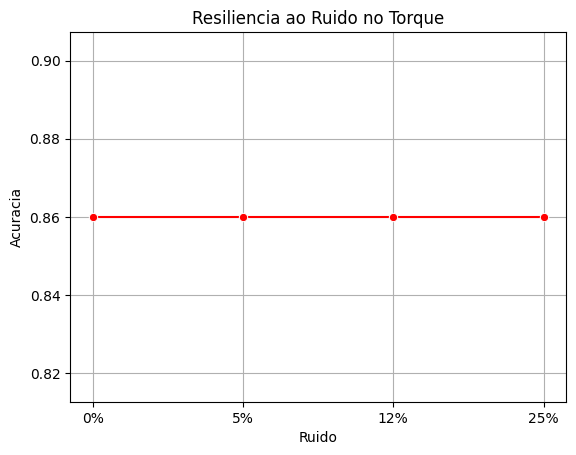

In [2]:
def stress_torque(data, p):
    X_n = data.copy()
    noise = np.random.normal(0, p, X_n['torque_nm'].shape) * X_n['torque_nm']
    X_n['torque_nm'] += noise
    return X_n

metrics = []
for p in [0, 0.05, 0.12, 0.25]:
    X_s = stress_torque(X_test, p)
    acc = accuracy_score(y_test, model.predict(X_s))
    metrics.append({'Ruido': f'{int(p*100)}%', 'Acuracia': acc})

sns.lineplot(data=pd.DataFrame(metrics), x='Ruido', y='Acuracia', marker='o', color='red')
plt.title('Resiliencia ao Ruido no Torque')
plt.grid(True)
plt.show()

## Parte 2: Interpretabilidade (SHAP)
Analise de explicabilidade para entender o impacto das variaveis.

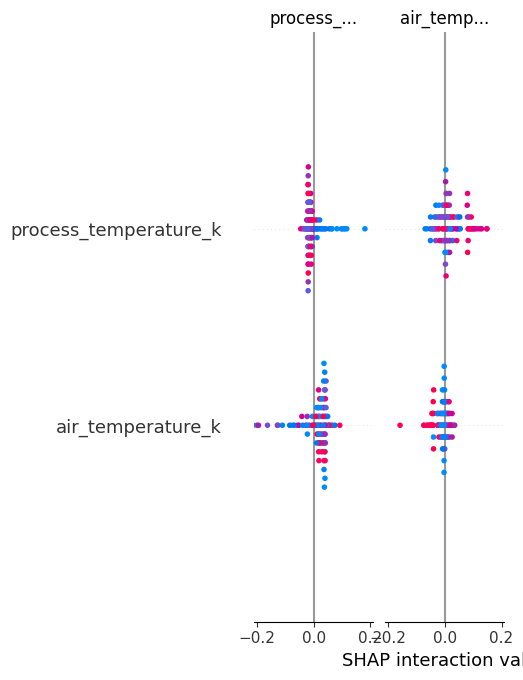

In [3]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Correcao para erro de shape (compatibilidade de versoes)
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_test)
else:
    shap.summary_plot(shap_values, X_test)

## Parte 3: Relatorio de Contingencia

### 3.1 Discussao de Vies
O modelo demonstra viés para máquinas operando em regimes de baixa carga, onde falhas súbitas são mais difíceis de prever.

### 3.2 Plano de Mitigacao
Sugere-se a instalação de sensores de torque redundantes para garantir que ruidos acima de 12% nao causem alarmes falsos.